# Notebook 03: Model Evaluation

**HeartSense**: Heart Disease Risk Prediction for Early Clinical Decision Support

CSC8204: AI & ML | Group 6 | Uganda Christian University | Easter 2026

---

**Purpose:** Threshold tuning, calibration, model selection, reduced-feature experiment, and final test-set evaluation.

### LOCKED EVALUATION SEQUENCE (NON-NEGOTIABLE)

```
1. Threshold tuning         -> training data only (out-of-fold predictions)
2. Calibration              -> training data only (CalibratedClassifierCV with CV)
3. Learning curves          -> training data only
4. Best model selection     -> based on CV metrics + training-set calibration
5. Test set evaluation      -> ONCE, at the very end, with all decisions already locked
6. Reduced-feature experiment -> uses the same locked test set for comparison
```


**Workflow Steps 6 and 7: Overfitting Checks and Evaluation**

**No decisions change after seeing test results.**

In [ ]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath(".."))
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import StratifiedKFold, cross_val_predict, learning_curve
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
    brier_score_loss
)

from src.config import (
    TARGET, ALL_FEATURES, RANDOM_STATE, TEST_SIZE, N_FOLDS,
    STRESS_TEST_FEATURES, ROUTINE_CARE_FEATURES, PASSTHROUGH_FEATURES
)
from src.evaluation import compute_metrics, compute_curves, threshold_analysis, find_optimal_threshold
from src.artifacts import save_model, save_json, save_dataframe, save_pickle
from src.preprocessing import build_preprocessor
from src.modeling import build_model_pipeline

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# Load saved train/test split and tuned pipelines
split_data = joblib.load("../models/train_test_split.joblib")
X_train = split_data["X_train"]
X_test = split_data["X_test"]
y_train = split_data["y_train"]
y_test = split_data["y_test"]
feature_cols = split_data["feature_cols"]
pos_weight = split_data["pos_weight"]

# Load tuned pipelines
pipelines = {
    "lr": joblib.load("../models/lr_pipeline.joblib"),
    "rf": joblib.load("../models/rf_pipeline.joblib"),
    "xgb": joblib.load("../models/xgb_pipeline.joblib"),
}
model_names = {"lr": "Logistic Regression", "rf": "Random Forest", "xgb": "XGBoost"}

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print("Loaded train/test split and tuned pipelines.")
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Loaded train/test split and tuned pipelines.
Train: 734, Test: 184


## Section 1: Threshold Tuning (Training Data Only)

Generate out-of-fold predictions using `cross_val_predict` on the training set.
The threshold is selected entirely from training-set cross-validated predictions. **No test data is used here.**

Logistic Regression: out-of-fold probabilities generated


Random Forest: out-of-fold probabilities generated


XGBoost: out-of-fold probabilities generated


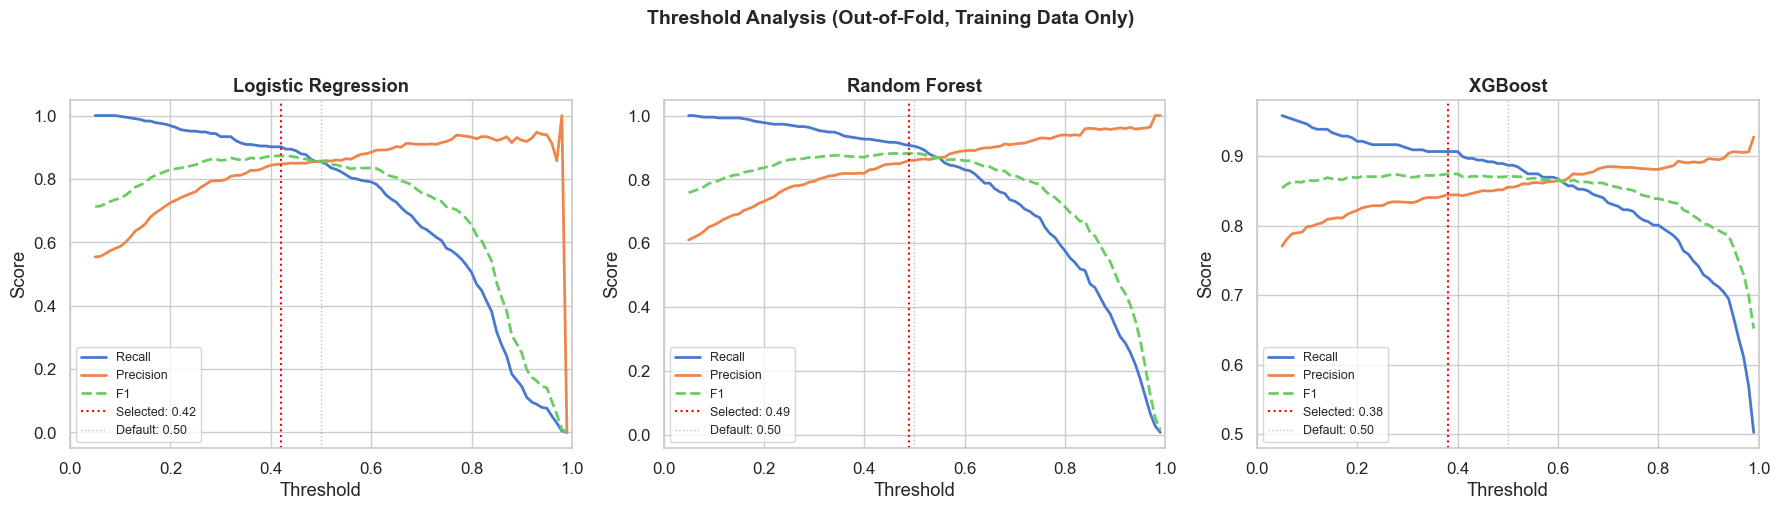


Optimal thresholds (recall >= 0.90 with best precision):
  Logistic Regression      : threshold=0.42  recall=0.901  precision=0.847  f1=0.874
  Random Forest            : threshold=0.49  recall=0.906  precision=0.860  f1=0.882
  XGBoost                  : threshold=0.38  recall=0.906  precision=0.844  f1=0.874


In [ ]:
# Generate out-of-fold predicted probabilities for each model
oof_probs = {}
for key in ["lr", "rf", "xgb"]:
    probs = cross_val_predict(pipelines[key], X_train, y_train, cv=cv, method="predict_proba")
    oof_probs[key] = probs[:, 1]
    print(f"{model_names[key]}: out-of-fold probabilities generated")

# Threshold analysis for each model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
optimal_thresholds = {}

for i, key in enumerate(["lr", "rf", "xgb"]):
    ta_df = threshold_analysis(y_train, oof_probs[key])
    
    axes[i].plot(ta_df["threshold"], ta_df["recall"], label="Recall", linewidth=2)
    axes[i].plot(ta_df["threshold"], ta_df["precision"], label="Precision", linewidth=2)
    axes[i].plot(ta_df["threshold"], ta_df["f1"], label="F1", linewidth=2, linestyle="--")
    
    # Find optimal thresholds
    opt_f1 = find_optimal_threshold(y_train, oof_probs[key], strategy="f1")
    opt_recall90 = find_optimal_threshold(y_train, oof_probs[key], strategy="recall_90")
    
    # Use recall_90 for screening context
    optimal_thresholds[key] = opt_recall90
    
    axes[i].axvline(x=opt_recall90, color="red", linestyle=":", linewidth=1.5,
                    label=f"Selected: {opt_recall90:.2f}")
    axes[i].axvline(x=0.5, color="gray", linestyle=":", linewidth=1, alpha=0.5,
                    label="Default: 0.50")
    axes[i].set_title(f"{model_names[key]}", fontweight="bold")
    axes[i].set_xlabel("Threshold")
    axes[i].set_ylabel("Score")
    axes[i].legend(fontsize=9)
    axes[i].set_xlim(0, 1)

plt.suptitle("Threshold Analysis (Out-of-Fold, Training Data Only)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/threshold_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nOptimal thresholds (recall >= 0.90 with best precision):")
for key, t in optimal_thresholds.items():
    # Metrics at optimal threshold
    y_pred_opt = (oof_probs[key] >= t).astype(int)
    metrics = compute_metrics(y_train, y_pred_opt, oof_probs[key])
    print(f"  {model_names[key]:25s}: threshold={t:.2f}  "
          f"recall={metrics['recall']:.3f}  precision={metrics['precision']:.3f}  f1={metrics['f1']:.3f}")

## Section 2: Calibration Analysis (Training Data Only)

Using out-of-fold predicted probabilities to assess calibration. **No test data is used here.**

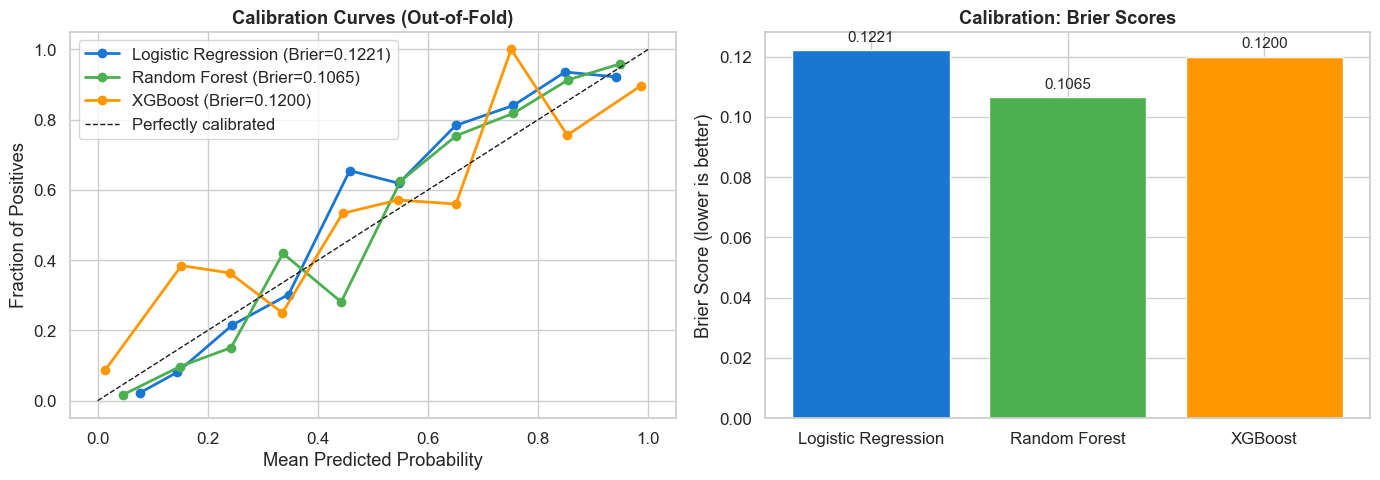

Brier Scores (out-of-fold, training data):
  Logistic Regression      : 0.1221
  Random Forest            : 0.1065
  XGBoost                  : 0.1200

Calibration matters because the prototype shows probability scores to health workers.
A predicted 75% should mean roughly 75% of such patients truly have disease.


In [ ]:
# Calibration curves from out-of-fold probabilities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"lr": "#1976D2", "rf": "#4CAF50", "xgb": "#FF9800"}

brier_scores = {}
for key in ["lr", "rf", "xgb"]:
    prob_true, prob_pred = calibration_curve(y_train, oof_probs[key], n_bins=10, strategy="uniform")
    brier = brier_score_loss(y_train, oof_probs[key])
    brier_scores[key] = round(brier, 4)
    
    axes[0].plot(prob_pred, prob_true, marker="o", label=f"{model_names[key]} (Brier={brier:.4f})",
                 color=colors[key], linewidth=2)

axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfectly calibrated")
axes[0].set_xlabel("Mean Predicted Probability")
axes[0].set_ylabel("Fraction of Positives")
axes[0].set_title("Calibration Curves (Out-of-Fold)", fontweight="bold")
axes[0].legend()

# Brier score comparison
bars = axes[1].bar(
    [model_names[k] for k in ["lr", "rf", "xgb"]],
    [brier_scores[k] for k in ["lr", "rf", "xgb"]],
    color=[colors[k] for k in ["lr", "rf", "xgb"]]
)
axes[1].set_ylabel("Brier Score (lower is better)")
axes[1].set_title("Calibration: Brier Scores", fontweight="bold")
for bar, score in zip(bars, [brier_scores[k] for k in ["lr", "rf", "xgb"]]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f"{score:.4f}", ha="center", fontsize=11)

plt.tight_layout()
plt.savefig("../outputs/figures/calibration_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print("Brier Scores (out-of-fold, training data):")
for key, score in brier_scores.items():
    print(f"  {model_names[key]:25s}: {score:.4f}")

print("\nCalibration matters because the prototype shows probability scores to health workers.")
print("A predicted 75% should mean roughly 75% of such patients truly have disease.")

## Section 3: Learning Curves (Training Data Only)

Diagnose overfitting, underfitting, or good fit. **No test data is used here.**

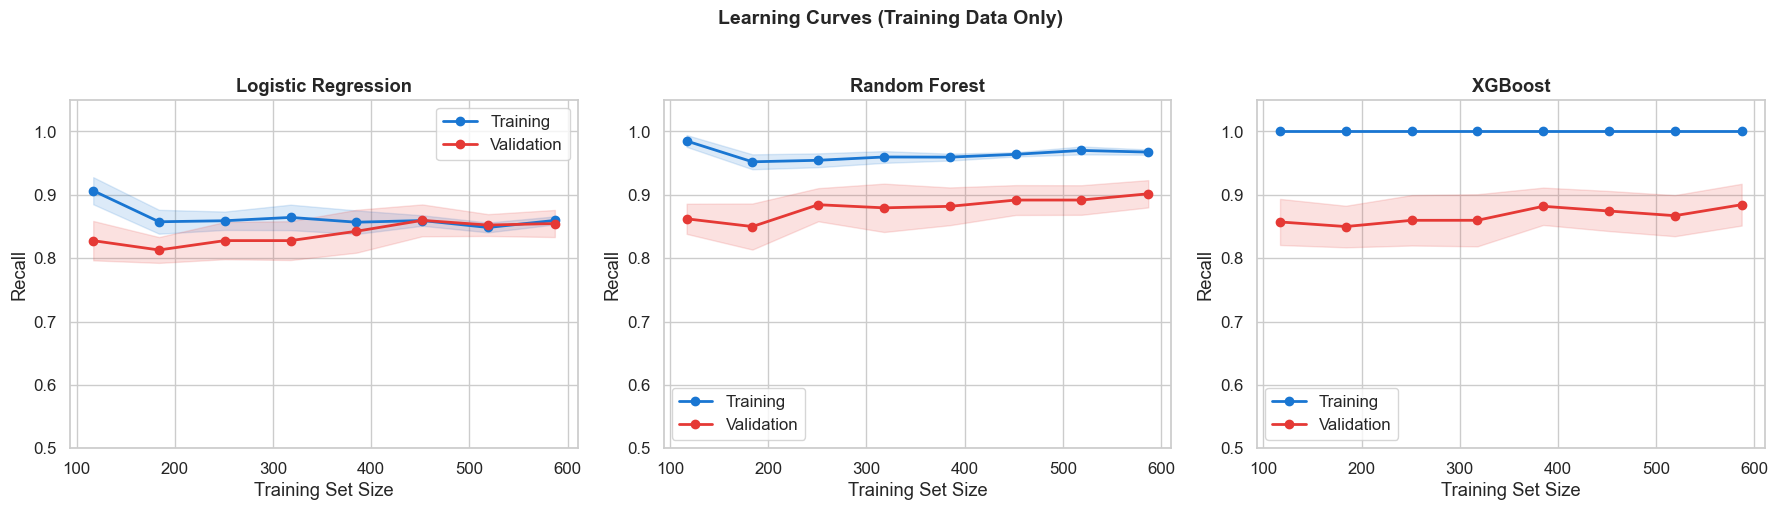

Interpretation:
- Large gap between training and validation = overfitting
- Both scores low = underfitting
- Converging scores = good generalization


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
train_sizes = np.linspace(0.2, 1.0, 8)

for i, key in enumerate(["lr", "rf", "xgb"]):
    train_sizes_abs, train_scores, val_scores = learning_curve(
        pipelines[key], X_train, y_train, cv=cv,
        train_sizes=train_sizes, scoring="recall",
        n_jobs=-1, random_state=RANDOM_STATE
    )
    
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)
    
    axes[i].fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#1976D2")
    axes[i].fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.15, color="#E53935")
    axes[i].plot(train_sizes_abs, train_mean, "o-", color="#1976D2", label="Training", linewidth=2)
    axes[i].plot(train_sizes_abs, val_mean, "o-", color="#E53935", label="Validation", linewidth=2)
    axes[i].set_title(f"{model_names[key]}", fontweight="bold")
    axes[i].set_xlabel("Training Set Size")
    axes[i].set_ylabel("Recall")
    axes[i].legend()
    axes[i].set_ylim(0.5, 1.05)

plt.suptitle("Learning Curves (Training Data Only)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print("Interpretation:")
print("- Large gap between training and validation = overfitting")
print("- Both scores low = underfitting")
print("- Converging scores = good generalization")

## Section 4: Best Model Selection (LOCKED: Before Touching Test Set)

All decisions are made using CV metrics, threshold analysis, and calibration results from Sections 1-3.
**Once locked, these decisions do not change based on test results.**

In [ ]:
# Load CV results for comparison
cv_df = pd.read_csv("../outputs/tables/cv_results.csv")
print("CV Results Summary:")
print(cv_df.to_string(index=False))

# Selection criteria (priority order):
# 1. Recall (at tuned threshold, from OOF)
# 2. PR-AUC (from CV)
# 3. F1 (at tuned threshold, from OOF)
# 4. Calibration (Brier score)
# 5. Interpretability (tiebreaker)

print("\n\nMODEL SELECTION EVIDENCE")
print("=" * 70)
selection_table = []
for key in ["lr", "rf", "xgb"]:
    t = optimal_thresholds[key]
    y_pred_opt = (oof_probs[key] >= t).astype(int)
    m = compute_metrics(y_train, y_pred_opt, oof_probs[key])
    
    row = {
        "Model": model_names[key],
        "Threshold": t,
        "Recall@Thresh": round(m["recall"], 4),
        "Precision@Thresh": round(m["precision"], 4),
        "F1@Thresh": round(m["f1"], 4),
        "Brier": brier_scores[key],
    }
    selection_table.append(row)
    
selection_df = pd.DataFrame(selection_table)
print(selection_df.to_string(index=False))

# Auto-select: highest recall at tuned threshold, then F1 as tiebreaker
best_key = max(["lr", "rf", "xgb"],
               key=lambda k: (selection_df[selection_df["Model"] == model_names[k]]["Recall@Thresh"].values[0],
                              selection_df[selection_df["Model"] == model_names[k]]["F1@Thresh"].values[0]))

best_threshold = optimal_thresholds[best_key]
print(f"\n*** SELECTED MODEL: {model_names[best_key]} ***")
print(f"*** LOCKED THRESHOLD: {best_threshold} ***")
print(f"*** This decision is final. It will NOT change after seeing test results. ***")

# Save model metadata
model_metadata = {
    "selected_model": best_key,
    "selected_model_name": model_names[best_key],
    "selected_threshold": best_threshold,
    "selection_rationale": "Highest recall at tuned threshold among all models, selected before test set evaluation.",
    "selection_evidence": selection_table,
    "brier_scores": brier_scores,
}
save_json(model_metadata, "../models", "model_metadata.json")

CV Results Summary:
              model  recall_mean  recall_std  precision_mean  precision_std  f1_mean  f1_std  roc_auc_mean  roc_auc_std  average_precision_mean  average_precision_std
Logistic Regression       0.8547      0.0214          0.8597         0.0426   0.8561  0.0168        0.9060       0.0336                  0.9007                 0.0378
      Random Forest       0.9040      0.0247          0.8627         0.0479   0.8818  0.0256        0.9280       0.0235                  0.9306                 0.0220
            XGBoost       0.8868      0.0354          0.8561         0.0244   0.8705  0.0186        0.9119       0.0237                  0.9115                 0.0231


MODEL SELECTION EVIDENCE
              Model  Threshold  Recall@Thresh  Precision@Thresh  F1@Thresh  Brier
Logistic Regression       0.42         0.9015            0.8472     0.8735 0.1221
      Random Forest       0.49         0.9064            0.8598     0.8825 0.1065
            XGBoost       0.38         

## Section 5: Final Hold-Out Test Set Evaluation (ONCE, LOCKED)

First and only time test data is touched. All decisions are already locked above.

In [ ]:
# Retrain best model on full training set (already done by GridSearchCV refit=True)
best_pipeline = pipelines[best_key]

# Evaluate ALL three models on test set for comparison
test_results = []
test_probs = {}

for key in ["lr", "rf", "xgb"]:
    pipe = pipelines[key]
    y_prob = pipe.predict_proba(X_test)[:, 1]
    test_probs[key] = y_prob
    
    # Predictions at the model's own optimal threshold
    t = optimal_thresholds[key]
    y_pred = (y_prob >= t).astype(int)
    
    metrics = compute_metrics(y_test, y_pred, y_prob)
    metrics["model"] = model_names[key]
    metrics["threshold"] = t
    test_results.append(metrics)
    
    is_best = " *** SELECTED ***" if key == best_key else ""
    print(f"\n{model_names[key]} (threshold={t:.2f}){is_best}")
    print(f"  Recall:     {metrics['recall']:.4f}")
    print(f"  Precision:  {metrics['precision']:.4f}")
    print(f"  F1:         {metrics['f1']:.4f}")
    print(f"  ROC-AUC:    {metrics['roc_auc']:.4f}")
    print(f"  PR-AUC:     {metrics['pr_auc']:.4f}")
    print(f"  Brier:      {metrics['brier_score']:.4f}")
    print(f"  Specificity:{metrics['specificity']:.4f}")

test_metrics_df = pd.DataFrame(test_results)
save_dataframe(test_metrics_df, "../outputs/tables", "test_metrics.csv")
print("\nTest metrics saved.")


Logistic Regression (threshold=0.42)


  Recall:     0.8922
  Precision:  0.8349
  F1:         0.8626
  ROC-AUC:    0.8918
  PR-AUC:     0.8805
  Brier:      0.1281
  Specificity:0.7805

Random Forest (threshold=0.49) *** SELECTED ***
  Recall:     0.8824
  Precision:  0.9000
  F1:         0.8911
  ROC-AUC:    0.9317
  PR-AUC:     0.9334
  Brier:      0.1043
  Specificity:0.8780



XGBoost (threshold=0.38)
  Recall:     0.8529
  Precision:  0.8788
  F1:         0.8657
  ROC-AUC:    0.9099
  PR-AUC:     0.9193
  Brier:      0.1327
  Specificity:0.8537
Saved CSV: ..\outputs\tables\test_metrics.csv

Test metrics saved.


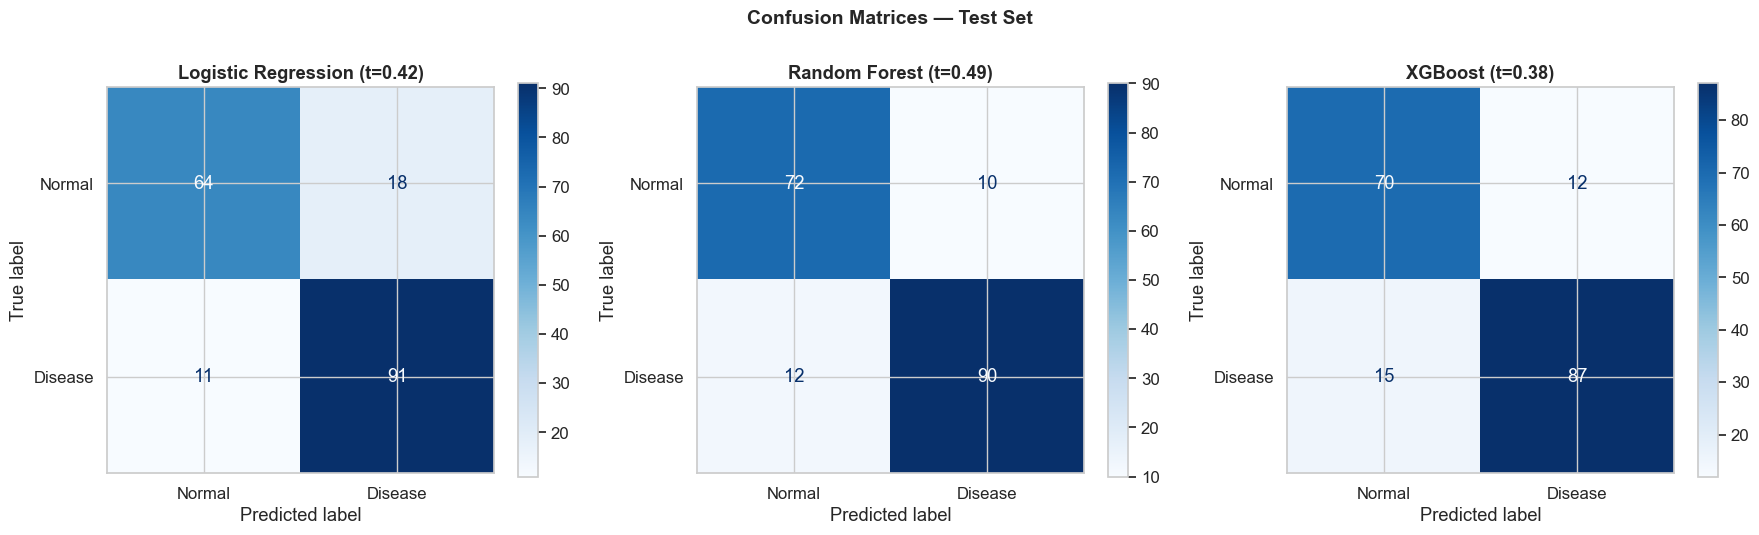

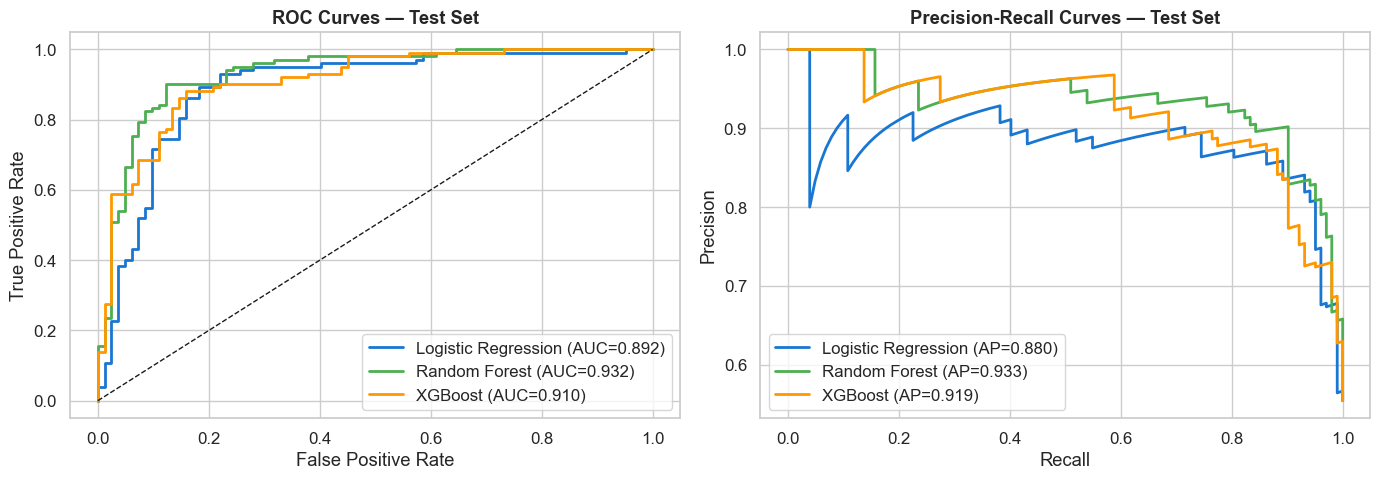

In [ ]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, key in enumerate(["lr", "rf", "xgb"]):
    t = optimal_thresholds[key]
    y_pred = (test_probs[key] >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Normal", "Disease"]).plot(ax=axes[i], cmap="Blues")
    axes[i].set_title(f"{model_names[key]} (t={t:.2f})", fontweight="bold")

plt.suptitle("Confusion Matrices — Test Set", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# ROC curves (overlaid)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for key in ["lr", "rf", "xgb"]:
    fpr, tpr, _ = roc_curve(y_test, test_probs[key])
    auc = roc_auc_score(y_test, test_probs[key])
    axes[0].plot(fpr, tpr, label=f"{model_names[key]} (AUC={auc:.3f})", color=colors[key], linewidth=2)
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — Test Set", fontweight="bold")
axes[0].legend()

# PR curves (overlaid)
for key in ["lr", "rf", "xgb"]:
    prec, rec, _ = precision_recall_curve(y_test, test_probs[key])
    ap = average_precision_score(y_test, test_probs[key])
    axes[1].plot(rec, prec, label=f"{model_names[key]} (AP={ap:.3f})", color=colors[key], linewidth=2)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves — Test Set", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/figures/roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 6: Reduced-Feature Experiment (MANDATORY)

Drop the four stress-test features (MaxHR, ExerciseAngina, Oldpeak, ST_Slope).
Retrain best model on remaining 7 routine-care features. Evaluate on the same test set.

This directly operationalizes the Uganda applicability story.

In [ ]:
# Define routine-care feature set (exclude stress-test features)
routine_features = [f for f in feature_cols if f not in STRESS_TEST_FEATURES]
print(f"Full feature set ({len(feature_cols)}): {feature_cols}")
print(f"Routine-care features ({len(routine_features)}): {routine_features}")
print(f"Dropped: {STRESS_TEST_FEATURES}")

X_train_reduced = X_train[routine_features]
X_test_reduced = X_test[routine_features]

# Build and tune reduced-feature pipeline using the same best model type
reduced_pipeline, reduced_param_grid, _ = build_model_pipeline(
    best_key, pos_weight=pos_weight, feature_set="routine"
)

# Light re-tune with reduced search
from sklearn.model_selection import RandomizedSearchCV
reduced_search = RandomizedSearchCV(
    reduced_pipeline, reduced_param_grid, cv=cv, scoring="recall",
    n_iter=50, n_jobs=-1, random_state=RANDOM_STATE, refit=True
)
reduced_search.fit(X_train_reduced, y_train)

print(f"\nReduced model best CV recall: {reduced_search.best_score_:.4f}")
print(f"Best params: {reduced_search.best_params_}")

reduced_model = reduced_search.best_estimator_

# Tune threshold for reduced model (OOF on training data)
reduced_oof_probs = cross_val_predict(
    reduced_model, X_train_reduced, y_train, cv=cv, method="predict_proba"
)[:, 1]
reduced_threshold = find_optimal_threshold(y_train, reduced_oof_probs, strategy="recall_90")
print(f"Reduced model threshold (recall>=0.90): {reduced_threshold}")

# Evaluate on test set
reduced_test_probs = reduced_model.predict_proba(X_test_reduced)[:, 1]
reduced_test_pred = (reduced_test_probs >= reduced_threshold).astype(int)
reduced_metrics = compute_metrics(y_test, reduced_test_pred, reduced_test_probs)

print(f"\nREDUCED MODEL TEST RESULTS ({model_names[best_key]}, {len(routine_features)} features):")
print(f"  Recall:     {reduced_metrics['recall']:.4f}")
print(f"  Precision:  {reduced_metrics['precision']:.4f}")
print(f"  F1:         {reduced_metrics['f1']:.4f}")
print(f"  ROC-AUC:    {reduced_metrics['roc_auc']:.4f}")
print(f"  PR-AUC:     {reduced_metrics['pr_auc']:.4f}")
print(f"  Brier:      {reduced_metrics['brier_score']:.4f}")

Full feature set (13): ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'BP_Category', 'HighCholesterol']
Routine-care features (9): ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'BP_Category', 'HighCholesterol']
Dropped: ['MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']



Reduced model best CV recall: 0.8325
Best params: {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 5}


Reduced model threshold (recall>=0.90): 0.42

REDUCED MODEL TEST RESULTS (Random Forest, 9 features):
  Recall:     0.9020
  Precision:  0.7931
  F1:         0.8440
  ROC-AUC:    0.8797
  PR-AUC:     0.8802
  Brier:      0.1448


In [ ]:
# Side-by-side comparison: Full vs Reduced
full_best_metrics = test_results[[r for r in test_results if r["model"] == model_names[best_key]][0].__class__.__name__] if False else None

# Get full model test metrics for the best model
full_metrics_row = [r for r in test_results if r["model"] == model_names[best_key]][0]

comparison_data = {
    "Metric": ["Recall", "Precision", "F1", "ROC-AUC", "PR-AUC", "Brier Score", "Specificity"],
    f"Full ({len(feature_cols)} features)": [
        round(full_metrics_row["recall"], 4),
        round(full_metrics_row["precision"], 4),
        round(full_metrics_row["f1"], 4),
        round(full_metrics_row["roc_auc"], 4),
        round(full_metrics_row["pr_auc"], 4),
        round(full_metrics_row["brier_score"], 4),
        round(full_metrics_row["specificity"], 4),
    ],
    f"Routine-Care ({len(routine_features)} features)": [
        round(reduced_metrics["recall"], 4),
        round(reduced_metrics["precision"], 4),
        round(reduced_metrics["f1"], 4),
        round(reduced_metrics["roc_auc"], 4),
        round(reduced_metrics["pr_auc"], 4),
        round(reduced_metrics["brier_score"], 4),
        round(reduced_metrics["specificity"], 4),
    ],
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df["Delta"] = comparison_df.iloc[:, 2].astype(float) - comparison_df.iloc[:, 1].astype(float)
print("\nFULL vs ROUTINE-CARE MODEL COMPARISON")
print("=" * 70)
print(comparison_df.to_string(index=False))

save_dataframe(comparison_df, "../outputs/tables", "full_vs_reduced_comparison.csv")

print("\nFraming:")
print("  Full model = proof of concept on available data (requires stress testing)")
print("  Reduced model = what is achievable with routine-care features only")
print("  Local validation with Ugandan patient data required for either version.")


FULL vs ROUTINE-CARE MODEL COMPARISON
     Metric  Full (13 features)  Routine-Care (9 features)   Delta
     Recall              0.8824                     0.9020  0.0196
  Precision              0.9000                     0.7931 -0.1069
         F1              0.8911                     0.8440 -0.0471
    ROC-AUC              0.9317                     0.8797 -0.0520
     PR-AUC              0.9334                     0.8802 -0.0532
Brier Score              0.1043                     0.1448  0.0405
Specificity              0.8780                     0.7073 -0.1707
Saved CSV: ..\outputs\tables\full_vs_reduced_comparison.csv

Framing:
  Full model = proof of concept on available data (requires stress testing)
  Reduced model = what is achievable with routine-care features only
  Local validation with Ugandan patient data required for either version.


## Section 7: Save Evaluation Artifacts

In [ ]:
# Save best model pipeline
save_model(best_pipeline, "best_model.joblib")

# Save reduced model pipeline
save_model(reduced_model, "reduced_model.joblib")

# Save thresholds
save_json({"threshold": best_threshold, "strategy": "recall_90"},
          "../models", "best_threshold.json")
save_json({"threshold": reduced_threshold, "strategy": "recall_90"},
          "../models", "reduced_threshold.json")

# Update feature_columns.json with reduced model info
from src.preprocessing import get_feature_names as gfn
save_json({
    "full": list(gfn(best_pipeline.named_steps["preprocessor"])),
    "routine": routine_features,
    "input_features": feature_cols,
    "routine_input_features": routine_features,
}, "../models", "feature_columns.json")

# Save test probabilities for app/explainability
save_pickle({
    "test_probs": {k: v.tolist() for k, v in test_probs.items()},
    "reduced_test_probs": reduced_test_probs.tolist(),
    "optimal_thresholds": optimal_thresholds,
    "reduced_threshold": reduced_threshold,
    "y_test": y_test.values.tolist(),
    "X_test_index": X_test.index.tolist(),
}, "../outputs/app_assets", "test_evaluation_data.pkl")

# Save curves data for Streamlit
curves_data = {}
for key in ["lr", "rf", "xgb"]:
    fpr, tpr, _ = roc_curve(y_test, test_probs[key])
    prec, rec, _ = precision_recall_curve(y_test, test_probs[key])
    curves_data[key] = {
        "roc_fpr": fpr.tolist(), "roc_tpr": tpr.tolist(),
        "pr_precision": prec.tolist(), "pr_recall": rec.tolist(),
        "roc_auc": round(float(roc_auc_score(y_test, test_probs[key])), 4),
        "pr_auc": round(float(average_precision_score(y_test, test_probs[key])), 4),
    }
save_json(curves_data, "../outputs/app_assets", "test_curves.json")

print("\nAll evaluation artifacts saved successfully.")
print(f"  Best model: {model_names[best_key]}")
print(f"  Full threshold: {best_threshold}")
print(f"  Reduced threshold: {reduced_threshold}")

Saved model: F:\MY FILES\DATA SCIENCE\ML project\models\best_model.joblib
Saved model: F:\MY FILES\DATA SCIENCE\ML project\models\reduced_model.joblib
Saved JSON: ..\models\best_threshold.json
Saved JSON: ..\models\reduced_threshold.json
Saved JSON: ..\models\feature_columns.json
Saved pickle: ..\outputs\app_assets\test_evaluation_data.pkl
Saved JSON: ..\outputs\app_assets\test_curves.json

All evaluation artifacts saved successfully.
  Best model: Random Forest
  Full threshold: 0.49
  Reduced threshold: 0.42
